# Diagnóstico do funil de propostas

Análise exploratória das propostas de crédito a partir de `data/raw/propostas_credito.csv`. O notebook audita e trata os dados, compara conversões e valores por recortes e termina com cenários de ação.

> As métricas são descritivas. Elas ajudam a localizar padrões e prioridades para investigação, mas não demonstram causalidade nem estimam receita.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "data" / "raw" / "propostas_credito.csv").exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        "Abra a pasta case_bari no VS Code e confira data/raw/propostas_credito.csv"
    )

ARQUIVO = ROOT / "data" / "raw" / "propostas_credito.csv"
GRAFICOS = ROOT / "outputs" / "graficos"
GRAFICOS.mkdir(parents=True, exist_ok=True)

print("CSV:", ARQUIVO.relative_to(ROOT))
print("Gráficos:", GRAFICOS.relative_to(ROOT))

CSV: data\raw\propostas_credito.csv
Gráficos: outputs\graficos


## Preparação do ambiente e localização dos arquivos

A primeira célula importa as bibliotecas, procura a raiz do projeto a partir da pasta atual e identifica o CSV. Ela também cria `outputs/graficos`, onde as etapas posteriores salvam as figuras.

In [4]:
bruto = pd.read_csv(ARQUIVO, dtype={"id_proposta": "string"})

obrigatorias = {
    "id_proposta", "data_entrada", "canal_origem", "uf", "tipo_imovel",
    "valor_imovel", "valor_solicitado", "score_credito", "prazo_meses",
    "idade_cliente", "flag_cliente_recorrente", "etapa_max_funil",
    "status_final", "data_assinatura_contrato", "taxa_juros_aa",
}

faltantes = obrigatorias - set(bruto.columns)
if faltantes:
    raise ValueError(f"Colunas obrigatórias ausentes: {sorted(faltantes)}")

print("Dimensão:", bruto.shape)
print(
    "Duplicatas completas:", bruto.duplicated().sum(),
    "| IDs repetidos:", bruto.id_proposta.duplicated().sum()
)
print("\nTipos e ausências:")
print(pd.DataFrame({
    "tipo": bruto.dtypes.astype(str),
    "ausentes": bruto.isna().sum()
}).to_string())

print("\nCategorias de canal no arquivo:")
print(bruto.canal_origem.value_counts(dropna=False).to_string())

print("\nStatus por etapa máxima:")
print(pd.crosstab(bruto.etapa_max_funil, bruto.status_final).to_string())

Dimensão: (6400, 19)
Duplicatas completas: 0 | IDs repetidos: 0

Tipos e ausências:
                             tipo  ausentes
id_proposta                string         0
data_entrada                  str         0
canal_origem                  str         0
cidade                        str         0
uf                            str         0
tipo_imovel                   str         0
valor_imovel                  str         0
valor_solicitado          float64         0
prazo_meses                 int64         0
score_credito               int64         0
idade_cliente               int64         0
renda_mensal_declarada    float64         0
flag_cliente_recorrente     int64         0
consultor_id                  str         0
etapa_max_funil             int64         0
status_final                  str         0
tempo_analise_dias          int64         0
data_assinatura_contrato      str      5159
taxa_juros_aa             float64      5159

Categorias de canal no arquivo:
can

## 2. Tratamento e decisões analíticas

A preparação padroniza datas e canais, converte valores numéricos e cria indicadores para contratação e registros suspeitos. A tabela de auditoria documenta as ocorrências encontradas e como cada uma será tratada.

In [5]:
dados = bruto.copy()

dados["data_entrada_dt"] = pd.to_datetime(
    dados.data_entrada, format="%Y-%m-%d", errors="coerce"
)
datas_br = pd.to_datetime(
    dados.data_entrada, format="%d/%m/%Y", errors="coerce"
)
dados["data_entrada_dt"] = dados.data_entrada_dt.fillna(datas_br)

dados["assinatura_dt"] = pd.to_datetime(
    dados.data_assinatura_contrato, format="%Y-%m-%d", errors="coerce"
)

dados["valor_imovel_num"] = pd.to_numeric(
    dados.valor_imovel.astype(str)
        .str.replace("R[$] *", "", regex=True)
        .str.strip(),
    errors="coerce"
)

chave_canal = dados.canal_origem.astype(str).str.strip().str.casefold()
mapa_canais = {
    "correspondente": "Correspondente",
    "organico": "Orgânico",
    "mídia paga": "Mídia paga",
    "indicação": "Indicação",
    "parceria": "Parceria",
}
dados["canal"] = chave_canal.map(mapa_canais)

dados["contratada"] = dados.status_final.eq("Contratada")
dados["etapa_invalida"] = ~dados.etapa_max_funil.between(1, 6)
dados["idade_suspeita"] = dados.idade_cliente.lt(18)
dados["assinatura_anterior"] = (
    dados.assinatura_dt.lt(dados.data_entrada_dt).fillna(False)
)
dados["mes_entrada"] = dados.data_entrada_dt.dt.to_period("M")
dados["ano_entrada"] = dados.data_entrada_dt.dt.year

auditoria = pd.DataFrame([
    (
        "Terreno",
        dados.tipo_imovel.eq("Terreno").sum(),
        "Excluir apenas da base analítica; preservar CSV bruto",
    ),
    (
        "Valor do imóvel com prefixo R$",
        dados.valor_imovel.astype(str).str.contains("R[$]", regex=True).sum(),
        "Remover prefixo e converter",
    ),
    (
        "Data de entrada DD/MM/AAAA",
        dados.data_entrada.astype(str).str.contains("/", regex=False).sum(),
        "Interpretar explicitamente como dia/mês/ano",
    ),
    (
        "Canal com caixa/espaço variante",
        (~dados.canal_origem.isin([
            "Correspondente", "Organico", "Mídia paga",
            "Indicação", "Parceria"
        ])).sum(),
        "Normalizar 4 variantes e padronizar acento de Organico",
    ),
    (
        "Idade menor que 18",
        dados.idade_suspeita.sum(),
        "Manter, sinalizar; não inferir elegibilidade",
    ),
    (
        "Etapa fora de 1–6",
        dados.etapa_invalida.sum(),
        "Manter em conversão, excluir de gráficos por etapa",
    ),
    (
        "Assinatura antes da entrada",
        dados.assinatura_anterior.sum(),
        "Manter status, não usar data para prazo contratual",
    ),
    (
        "LTV ausente como coluna",
        int("ltv" not in dados),
        "Calcular LTV solicitado; escopo da política pendente",
    ),
    (
        "Unidade ambígua da taxa",
        int("taxa_juros_aa" in dados),
        "Não usar a taxa até esclarecimento",
    ),
], columns=["ocorrência", "linhas/indicador", "decisão"])

print(auditoria.to_string(index=False))

analise = dados.loc[dados.tipo_imovel.ne("Terreno")].copy()
analise["ltv_solicitado"] = (
    analise.valor_solicitado / analise.valor_imovel_num
)

campos_essenciais = [
    "data_entrada_dt", "valor_imovel_num", "valor_solicitado", "canal"
]
if analise[campos_essenciais].isna().any().any():
    raise ValueError(
        "Falha na conversão de campos essenciais; investigue antes das métricas"
    )

if (analise.valor_imovel_num <= 0).any():
    raise ValueError("Valor de imóvel não positivo; LTV indefinido")

assert (
    len(analise) + bruto.tipo_imovel.eq("Terreno").sum() == len(bruto)
)

print(
    f"\nBase analítica: {len(analise):,} / {len(bruto):,} propostas; "
    f"contratadas: {analise.contratada.sum():,}"
)
print(
    "Ausências de assinatura/taxa nas não contratadas:",
    analise.loc[
        ~analise.contratada,
        ["data_assinatura_contrato", "taxa_juros_aa"]
    ].isna().all().to_dict()
)
print(
    "LTV solicitado > 60%:",
    (analise.ltv_solicitado > .60).sum(),
    "| contratadas nesse grupo:",
    analise.loc[analise.ltv_solicitado > .60, "contratada"].sum()
)

                     ocorrência  linhas/indicador                                                decisão
                        Terreno               535  Excluir apenas da base analítica; preservar CSV bruto
 Valor do imóvel com prefixo R$                 3                            Remover prefixo e converter
     Data de entrada DD/MM/AAAA                 3            Interpretar explicitamente como dia/mês/ano
Canal com caixa/espaço variante                 4 Normalizar 4 variantes e padronizar acento de Organico
             Idade menor que 18                 1           Manter, sinalizar; não inferir elegibilidade
              Etapa fora de 1–6                 1     Manter em conversão, excluir de gráficos por etapa
    Assinatura antes da entrada                 1     Manter status, não usar data para prazo contratual
        LTV ausente como coluna                 1   Calcular LTV solicitado; escopo da política pendente
        Unidade ambígua da taxa                 1      

**Critérios importantes**

- Os 535 registros de `Terreno` são excluídos apenas da base analítica; o CSV bruto é preservado.
- Registros suspeitos são sinalizados e mantidos, sem inferir elegibilidade ou corrigir dados sem evidência.
- Como o CSV não contém uma coluna `ltv`, calcula-se o LTV solicitado (`valor_solicitado / valor_imovel`). Isso não confirma qual valor a política de crédito usa.
- A unidade de `taxa_juros_aa` permanece ambígua; por isso, a taxa não entra nas análises.

Não contratadas por etapa máxima:
                 propostas  valor_mi  participacao_pct
etapa_max_funil                                       
1                      256     97.90              5.31
2                      909    346.83             18.80
3                     1657    649.85             35.23
4                     1151    453.76             24.60
5                      764    296.12             16.05

Por status (não contratadas):
                       propostas  valor_mi
status_final                              
Sem retorno                 1495    575.14
Desistiu                    1392    550.65
Reprovada crédito            844    325.02
Problema garantia            608    241.08
Documentação pendente        398    152.57

Maior etapa: 3 | exposição: R$ 649,8 mi


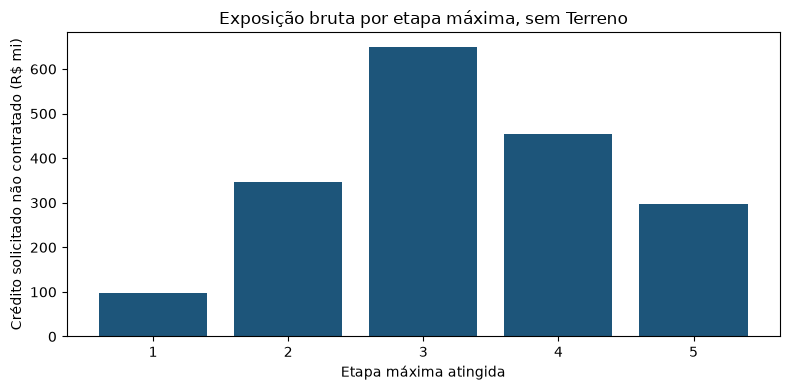

In [6]:
def reais_milhoes(valor):
    return (
        f"R$ {valor / 1e6:,.1f} mi"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

perdas = analise.loc[
    ~analise.contratada & ~analise.etapa_invalida
]

por_etapa = perdas.groupby("etapa_max_funil").agg(
    propostas=("id_proposta", "size"),
    valor_solicitado=("valor_solicitado", "sum"),
).reindex(range(1, 6), fill_value=0)

por_etapa["participacao_valor"] = (
    por_etapa.valor_solicitado / por_etapa.valor_solicitado.sum()
)

por_status = perdas.groupby("status_final").agg(
    propostas=("id_proposta", "size"),
    valor_solicitado=("valor_solicitado", "sum"),
).sort_values("valor_solicitado", ascending=False)

assert por_etapa.propostas.sum() == len(perdas)
assert np.isclose(
    por_etapa.valor_solicitado.sum(),
    perdas.valor_solicitado.sum()
)

print("Não contratadas por etapa máxima:")
print(
    por_etapa.assign(
        valor_mi=por_etapa.valor_solicitado / 1e6,
        participacao_pct=por_etapa.participacao_valor * 100,
    )[["propostas", "valor_mi", "participacao_pct"]]
    .round(2).to_string()
)

print("\nPor status (não contratadas):")
print(
    por_status.assign(
        valor_mi=por_status.valor_solicitado / 1e6
    )[["propostas", "valor_mi"]]
    .round(2).to_string()
)

print(
    "\nMaior etapa:",
    int(por_etapa.valor_solicitado.idxmax()),
    "| exposição:",
    reais_milhoes(por_etapa.valor_solicitado.max()),
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    por_etapa.index.astype(str),
    por_etapa.valor_solicitado / 1e6,
    color="#1d557a",
)
ax.set(
    xlabel="Etapa máxima atingida",
    ylabel="Crédito solicitado não contratado (R$ mi)",
    title="Exposição bruta por etapa máxima, sem Terreno",
)
fig.tight_layout()
fig.savefig(GRAFICOS / "valor_por_etapa.png", dpi=160)
plt.show()
plt.close(fig)

## 3. Crédito solicitado não contratado por etapa máxima

A análise considera propostas não contratadas e agrupa cada uma pela etapa mais avançada registrada. O gráfico mostra a soma do crédito solicitado em cada grupo, não uma perda financeira realizada nem um valor garantido de recuperação.

As etapas 1–5 são grupos de **etapa máxima**, não taxas de conversão entre transições. Compare quantidade e valor solicitado lado a lado; o maior valor pode orientar uma investigação operacional, mas não prova que a etapa causou a desistência. Os nomes operacionais das etapas não estão definidos nos dados disponíveis.

## 4. Conversão por coorte de entrada

A conversão é calculada como propostas contratadas divididas pelo total de propostas da coorte. A visão anual inclui intervalos de Wilson para dar contexto à incerteza; a comparação entre 2024 e 2025 é uma diferença descritiva aproximada.

A série mensal ajuda a localizar variações ao longo do tempo, mas não identifica suas causas. Meses recentes podem ter propostas ainda em andamento, então compare coortes com tempo de maturação semelhante e evite interpretar variação mensal isolada como tendência consolidada.

Conversão global: 19.23%

Por ano de entrada:
             propostas  contratos  conversao  ic_inf  ic_sup
ano_entrada                                                 
2024              2506        509     0.2031  0.1878  0.2193
2025              3359        619     0.1843  0.1715  0.1978

Diferença 2025 - 2024: -1.88 p.p.; faixa aproximada 95%: [-3.93, +0.17] p.p.

Meses de entrada (últimos 12):
             propostas  contratos  conversao
mes_entrada                                 
2025-01            420         86      0.205
2025-02            439         74      0.169
2025-03            482         85      0.176
2025-04            412         74      0.180
2025-05            357         78      0.218
2025-06            343         69      0.201
2025-07            288         49      0.170
2025-08            242         41      0.169
2025-09            158         28      0.177
2025-10            127         20      0.157
2025-11             65          7      0.108
2025-12        

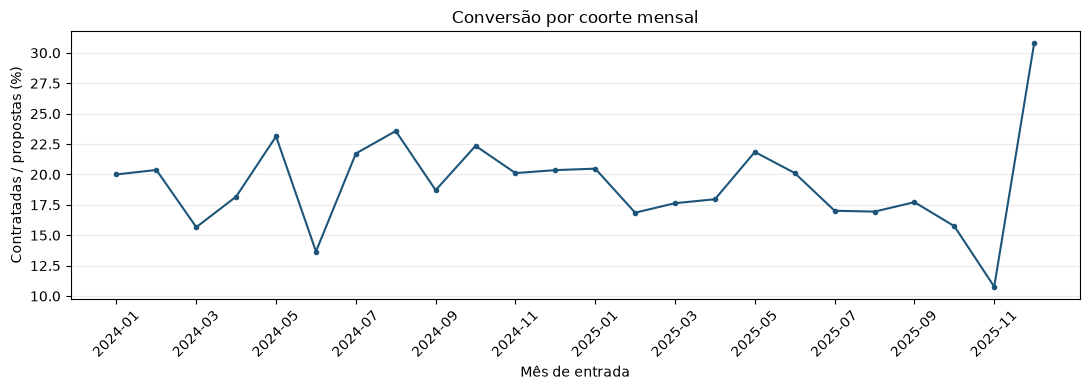

In [7]:
def intervalo_wilson(sucessos, total, z=1.96):
    if total == 0:
        return np.nan, np.nan

    p = sucessos / total
    centro = (p + z*z/(2*total)) / (1 + z*z/total)
    margem = z * np.sqrt(
        p*(1-p)/total + z*z/(4*total*total)
    ) / (1 + z*z/total)

    return centro - margem, centro + margem

anual = analise.groupby("ano_entrada").contratada.agg(
    propostas="size",
    contratos="sum",
    conversao="mean",
)

anual[["ic_inf", "ic_sup"]] = [
    intervalo_wilson(row.contratos, row.propostas)
    for row in anual.itertuples()
]

mensal = analise.groupby("mes_entrada").contratada.agg(
    propostas="size",
    contratos="sum",
    conversao="mean",
)

print("Conversão global:", f"{analise.contratada.mean():.2%}")
print("\nPor ano de entrada:")
print(anual.round(4).to_string())

if {2024, 2025}.issubset(anual.index):
    p0 = anual.loc[2024, "conversao"]
    p1 = anual.loc[2025, "conversao"]
    n0 = anual.loc[2024, "propostas"]
    n1 = anual.loc[2025, "propostas"]

    dif = p1 - p0
    erro = np.sqrt(
        p0*(1-p0)/n0 + p1*(1-p1)/n1
    )

    print(
        f"\nDiferença 2025 - 2024: {dif*100:+.2f} p.p.; "
        f"faixa aproximada 95%: "
        f"[{(dif-1.96*erro)*100:+.2f}, "
        f"{(dif+1.96*erro)*100:+.2f}] p.p."
    )

print("\nMeses de entrada (últimos 12):")
print(mensal.tail(12).round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    range(len(mensal)),
    100 * mensal.conversao,
    marker="o",
    ms=3,
    color="#1d557a",
)
ax.set_xticks(
    range(0, len(mensal), 2),
    mensal.index.astype(str)[::2],
    rotation=45,
)
ax.set(
    ylabel="Contratadas / propostas (%)",
    xlabel="Mês de entrada",
    title="Conversão por coorte mensal",
)
ax.grid(axis="y", alpha=.25)
fig.tight_layout()
fig.savefig(GRAFICOS / "conversao_mensal.png", dpi=160)
plt.show()
plt.close(fig)

## 5. Conversão por canal

Cada canal é comparado pela proporção de propostas contratadas, com volume e intervalos de Wilson para contextualizar as diferenças. A tabela por ano ajuda a verificar se a composição temporal pode estar relacionada ao resultado observado.

Uma conversão maior ou menor não demonstra, por si só, efeito causal do canal: perfil das propostas, período e outros fatores podem diferir entre grupos. Trate os resultados como sinal para investigação, não como avaliação isolada de desempenho.

                propostas  contratos  conversao  ic_inf  ic_sup  valor_mi
canal                                                                    
Correspondente       1627        223      0.137   0.121   0.155   634.510
Orgânico             1273        255      0.200   0.179   0.223   494.970
Mídia paga           1166        250      0.214   0.192   0.239   444.203
Indicação             910        197      0.216   0.191   0.244   346.545
Parceria              889        203      0.228   0.202   0.257   340.932

Canal por ano de entrada:
                            propostas  conversao
ano_entrada canal                               
2024        Correspondente        663     0.1463
            Indicação             367     0.2343
            Mídia paga            512     0.2441
            Orgânico              559     0.1932
            Parceria              405     0.2296
2025        Correspondente        964     0.1307
            Indicação             543     0.2044
            Mí

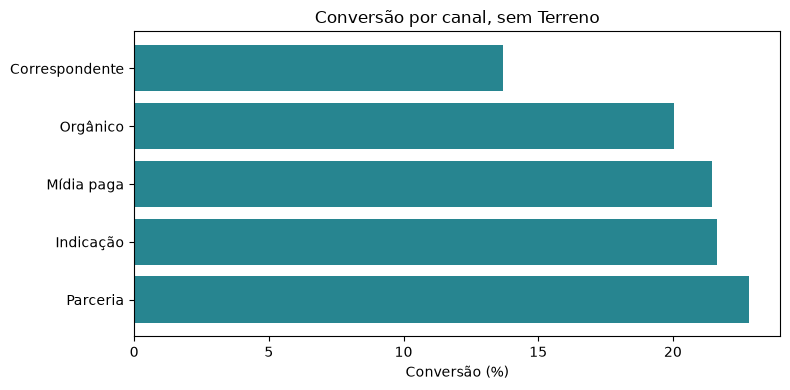

In [8]:
canais = analise.groupby("canal").agg(
    propostas=("id_proposta", "size"),
    contratos=("contratada", "sum"),
    valor_solicitado=("valor_solicitado", "sum"),
)

canais["conversao"] = canais.contratos / canais.propostas
canais[["ic_inf", "ic_sup"]] = [
    intervalo_wilson(row.contratos, row.propostas)
    for row in canais.itertuples()
]
canais = canais.sort_values("conversao")

print(
    canais.assign(
        valor_mi=canais.valor_solicitado / 1e6
    )[[
        "propostas", "contratos", "conversao",
        "ic_inf", "ic_sup", "valor_mi"
    ]].round(3).to_string()
)

print("\nCanal por ano de entrada:")
canal_ano = analise.groupby(
    ["ano_entrada", "canal"]
).contratada.agg(
    propostas="size",
    conversao="mean",
)
print(canal_ano.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    canais.index,
    100 * canais.conversao,
    color="#278590",
)
ax.set(
    xlabel="Conversão (%)",
    title="Conversão por canal, sem Terreno",
)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(GRAFICOS / "conversao_canais.png", dpi=160)
plt.show()
plt.close(fig)

## 6. Características associadas à contratação

As tabelas comparam a proporção contratada entre faixas de LTV solicitado, score, ticket, tipo de imóvel, prazo, UF e recorrência. Verifique também o número de propostas por grupo: percentuais baseados em grupos pequenos podem variar bastante.

São associações descritivas, não efeitos causais nem regras de aprovação. Em particular, as faixas de LTV usam o valor solicitado e não substituem a definição de LTV adotada pela política de crédito.

In [9]:
analise["faixa_ltv"] = pd.cut(
    analise.ltv_solicitado,
    bins=[-np.inf, .40, .60, .80, np.inf],
    labels=["Até 40%", ">40–60%", ">60–80%", ">80%"],
)

analise["faixa_score"] = pd.cut(
    analise.score_credito,
    bins=[-np.inf, 600, 650, 700, 750, np.inf],
    labels=["Até 600", "601–650", "651–700", "701–750", ">750"],
)

analise["faixa_ticket"] = pd.qcut(
    analise.valor_solicitado,
    q=4,
    labels=["Q1 menor", "Q2", "Q3", "Q4 maior"],
    duplicates="drop",
)

analise["faixa_prazo"] = pd.cut(
    analise.prazo_meses,
    bins=[0, 84, 120, 180, np.inf],
    labels=["Até 84", "85–120", "121–180", ">180"],
)

def tabela_conversao(coluna):
    tabela = analise.groupby(
        coluna, observed=True
    ).contratada.agg(
        propostas="size",
        contratos="sum",
        conversao="mean",
    )
    return tabela.assign(
        conversao_pct=(100 * tabela.conversao).round(2)
    )[["propostas", "contratos", "conversao_pct"]]

grupos = [
    ("LTV solicitado", "faixa_ltv"),
    ("Score", "faixa_score"),
    ("Ticket solicitado, quartis", "faixa_ticket"),
    ("Tipo de imóvel", "tipo_imovel"),
    ("Prazo em meses", "faixa_prazo"),
    ("UF", "uf"),
    ("Cliente recorrente", "flag_cliente_recorrente"),
]

for nome, coluna in grupos:
    print("\n" + nome)
    print(tabela_conversao(coluna).to_string())


LTV solicitado
           propostas  contratos  conversao_pct
faixa_ltv                                     
Até 40%         1150        235          20.43
>40–60%         3811        784          20.57
>60–80%          904        109          12.06

Score
             propostas  contratos  conversao_pct
faixa_score                                     
Até 600           1060        102           9.62
601–650           1297        206          15.88
651–700           1482        275          18.56
701–750           1208        284          23.51
>750               818        261          31.91

Ticket solicitado, quartis
              propostas  contratos  conversao_pct
faixa_ticket                                     
Q1 menor           1467        303          20.65
Q2                 1466        307          20.94
Q3                 1466        261          17.80
Q4 maior           1466        257          17.53

Tipo de imóvel
                propostas  contratos  conversao_pct
tip

## 7. Cenários de ação

Os três cenários aplicam premissas simples às bases selecionadas: ganho de 2 pontos percentuais para Correspondentes e conversão de 5% do valor nas propostas sem retorno da etapa 3 e com documentação pendente na etapa 5.

Os impactos são cenários de **crédito contratado**, não receita, previsão ou efeito observado de uma intervenção. As bases podem se sobrepor; portanto, os impactos não devem ser somados. Use os valores para dimensionar hipóteses de piloto e valide-os com um teste controlado.

In [10]:
sem_retorno_et3 = analise.loc[
    (analise.etapa_max_funil == 3)
    & analise.status_final.eq("Sem retorno")
]

doc_et5 = analise.loc[
    (analise.etapa_max_funil == 5)
    & analise.status_final.eq("Documentação pendente")
]

corr = analise.loc[
    analise.canal.eq("Correspondente")
]

cenarios = pd.DataFrame([
    {
        "prioridade": 1,
        "ação": (
            "Piloto de qualificação e acompanhamento "
            "de Correspondentes"
        ),
        "base_n": len(corr),
        "base_valor": corr.valor_solicitado.sum(),
        "premissa": "+2 p.p. de conversão no mesmo ticket médio",
        "taxa": .02,
        "impacto_credito": corr.valor_solicitado.sum() * .02,
    },
    {
        "prioridade": 2,
        "ação": (
            "Contato ativo para Sem retorno após análise "
            "de crédito (etapa 3)"
        ),
        "base_n": len(sem_retorno_et3),
        "base_valor": sem_retorno_et3.valor_solicitado.sum(),
        "premissa": "5% desse valor vira contrato",
        "taxa": .05,
        "impacto_credito": (
            sem_retorno_et3.valor_solicitado.sum() * .05
        ),
    },
    {
        "prioridade": 3,
        "ação": (
            "Checklist e lembretes de documentação "
            "na etapa 5"
        ),
        "base_n": len(doc_et5),
        "base_valor": doc_et5.valor_solicitado.sum(),
        "premissa": "5% desse valor vira contrato",
        "taxa": .05,
        "impacto_credito": doc_et5.valor_solicitado.sum() * .05,
    },
])

print(
    cenarios.assign(
        base_mi=cenarios.base_valor / 1e6,
        impacto_mi=cenarios.impacto_credito / 1e6,
    )[[
        "prioridade", "ação", "base_n",
        "base_mi", "premissa", "impacto_mi"
    ]].round(2).to_string(index=False)
)

print(
    "\nAs estimativas são cenários de crédito contratado, "
    "não de receita; não são aditivas."
)

 prioridade                                                             ação  base_n  base_mi                                   premissa  impacto_mi
          1       Piloto de qualificação e acompanhamento de Correspondentes    1627   634.51 +2 p.p. de conversão no mesmo ticket médio       12.69
          2 Contato ativo para Sem retorno após análise de crédito (etapa 3)     526   207.69               5% desse valor vira contrato       10.38
          3                 Checklist e lembretes de documentação na etapa 5     398   152.57               5% desse valor vira contrato        7.63

As estimativas são cenários de crédito contratado, não de receita; não são aditivas.
